# Inventory Policy And Slotting Readiness

Shows empirical lead-time `(s,S)` decisions, service classes, handling-unit rounding and physical space requirements used by the optimizer.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "outputs").exists():
    ROOT = Path("Ai miroservices/modeling/project_operational_baseline").resolve()
OUT = ROOT / "outputs"
EVAL = OUT / "evaluator"
sns.set_theme(style="whitegrid")

In [2]:
policy=pd.read_csv(OUT/'inventory_policy.csv.gz')
materials=pd.read_csv(OUT/'materials.csv.gz')
locations=pd.read_csv(OUT/'locations.csv.gz')
display(policy.groupby('amalgamated_class')[['target_service_level','safety_stock','required_handling_units']].agg(['mean','median','sum']))

target_service_level                safety_stock             \
                                  mean median    sum          mean     median   
amalgamated_class                                                               
AF                                0.98   0.98  26.46    469.281852    143.570   
AM                                0.98   0.98   0.98   3150.320000   3150.320   
AS                                0.97   0.97   0.97  10028.380000  10028.380   
BF                                0.98   0.98  15.68    278.735000    135.055   
BM                                0.95   0.95   0.95   1706.380000   1706.380   
CF                                0.92   0.92  21.16    185.105652     14.540   
CM                                0.92   0.92   2.76    233.333333    249.660   
CS                                0.92   0.92   7.36    168.323750     20.120   

                            required_handling_units              
                        sum                    mean median  sum  
amalgamated_class                                                
AF                 12670.61               12.333333    8.0  333  
AM                  3150.32                7.000000    7.0    7  
AS                 10028.38                6.000000    6.0    6  
BF                  4459.76                7.812500    7.5  125  
BM                  1706.38                2.000000    2.0    2  
CF                  4257.43                5.478261    6.0  126  
CM                   700.00                4.000000    5.0   12  
CS                  1346.59                6.125000    5.5   49

In [3]:
assert (policy.max_stock>=policy.min_stock).all()
assert (policy.order_quantity%policy.units_per_handling_unit==0).all()
print('Policy feasibility checks passed.')
print('Required handling units:',policy.required_handling_units.sum(),'Available pallet-capacity units:',locations.max_pallet_capacity.sum())

Policy feasibility checks passed.
Required handling units: 660 Available pallet-capacity units: 1200


Required pallet positions: 199 Available pallet positions: 1200


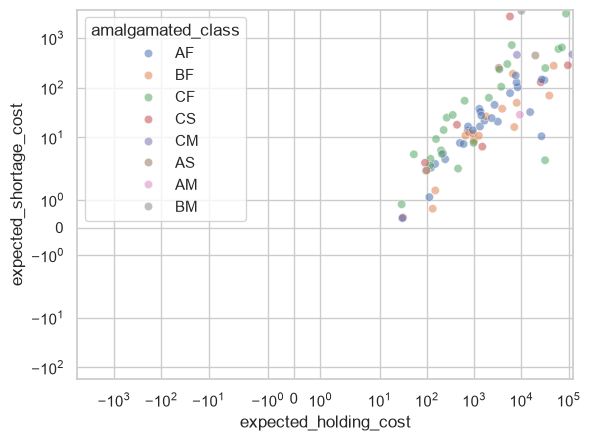

In [4]:
print('Required pallet positions:',policy.required_pallet_positions.sum(),'Available pallet positions:',locations.max_pallet_capacity.sum())
sns.scatterplot(data=policy,x='expected_holding_cost',y='expected_shortage_cost',hue='amalgamated_class',alpha=.55); plt.xscale('symlog'); plt.yscale('symlog'); plt.show()

,model_name,under_to_over_cost_ratio,decision_quantile,forecast_source,shortage_units,inventory_holding_units,safety_stock_units,fill_rate_proxy,weighted_total_cost_proxy,claim_boundary,population
12,EXTRA_TREES,1:1,0.500000,point_forecast,45291.588246,71176.160100,0.000000,0.951292,116467.748345,Sensitivity proxy only until shortage and hold...,RM_PM_PRIMARY
20,EXTRA_TREES_RESPONSIVE,1:1,0.500000,point_forecast,46532.302963,71595.852667,0.000000,0.949957,118128.155629,Sensitivity proxy only until shortage and hold...,RM_PM_PRIMARY
16,EXTRA_TREES_DAMPED_TREND,1:1,0.500000,point_forecast,52488.463978,74687.960211,0.000000,0.943552,127176.424190,Sensitivity proxy only until shortage and hold...,RM_PM_PRIMARY
24,LIGHTGBM,1:1,0.500000,point_forecast,57602.628431,70377.040836,0.000000,0.938052,127979.669267,Sensitivity proxy only until shortage and hold...,RM_PM_PRIMARY
0,CONV1D_ATTENTION_GLOBAL,1:1,0.500000,p50,84487.996666,58288.465260,0.000000,0.909139,142776.461926,Sensitivity proxy only until shortage and hold...,RM_PM_PRIMARY
8,ETS_A_N_A,1:1,0.500000,point_forecast,68181.875226,75100.513359,0.000000,0.926675,143282.388585,Sensitivity proxy only until shortage and hold...,RM_PM_PRIMARY
32,SEASONAL_NAIVE,1:1,0.500000,point_forecast,48760.062000,104926.110000,0.000000,0.947562,153686.172000,Sensitivity proxy only until shortage and hold...,RM_PM_PRIMARY
28,MOVING_AVERAGE_3,1:1,0.500000,point_forecast,41094.733715,115334.412770,0.000000,0.955805,156429.146485,Sensitivity proxy only until shortage and hold...,RM_PM_PRIMARY
4,CROSTON_SBA,1:1,0.500000,point_forecast,130067.857861,42266.412445,0.000000,0.860120,172334.270307,Sensitivity proxy only until shortage and hold...,RM_PM_PRIMARY
13,EXTRA_TREES,2:1,0.666667,point_forecast,45291.588246,71176.160100,0.000000,0.951292,161759.336591,Sensitivity proxy only until shortage and hold...,RM_PM_PRIMARY


,model_name,under_to_over_cost_ratio,decision_quantile,forecast_source,shortage_units,inventory_holding_units,safety_stock_units,fill_rate_proxy,weighted_total_cost_proxy,claim_boundary,population
48,EXTRA_TREES,1:1,0.500000,point_forecast,15696.604833,13809.485897,0.000000,0.932639,29506.090730,Sensitivity proxy only until shortage and hold...,FG_SECONDARY
56,EXTRA_TREES_RESPONSIVE,1:1,0.500000,point_forecast,17033.648492,13086.503817,0.000000,0.926902,30120.152308,Sensitivity proxy only until shortage and hold...,FG_SECONDARY
60,LIGHTGBM,1:1,0.500000,point_forecast,17899.538465,13139.375005,0.000000,0.923186,31038.913470,Sensitivity proxy only until shortage and hold...,FG_SECONDARY
52,EXTRA_TREES_DAMPED_TREND,1:1,0.500000,point_forecast,17985.248372,18490.023546,0.000000,0.922818,36475.271918,Sensitivity proxy only until shortage and hold...,FG_SECONDARY
36,CONV1D_ATTENTION_GLOBAL,1:1,0.500000,p50,24706.532227,13747.887589,0.000000,0.893974,38454.419815,Sensitivity proxy only until shortage and hold...,FG_SECONDARY
44,ETS_A_N_A,1:1,0.500000,point_forecast,22462.164703,20276.728977,0.000000,0.903606,42738.893679,Sensitivity proxy only until shortage and hold...,FG_SECONDARY
68,SEASONAL_NAIVE,1:1,0.500000,point_forecast,21058.094000,27981.094000,0.000000,0.909631,49039.188000,Sensitivity proxy only until shortage and hold...,FG_SECONDARY
40,CROSTON_SBA,1:1,0.500000,point_forecast,38806.724916,11348.184847,0.000000,0.833464,50154.909763,Sensitivity proxy only until shortage and hold...,FG_SECONDARY
64,MOVING_AVERAGE_3,1:1,0.500000,point_forecast,18995.318557,31921.990230,0.000000,0.918483,50917.308787,Sensitivity proxy only until shortage and hold...,FG_SECONDARY
49,EXTRA_TREES,2:1,0.666667,point_forecast,15696.604833,13809.485897,0.000000,0.932639,45202.695563,Sensitivity proxy only until shortage and hold...,FG_SECONDARY


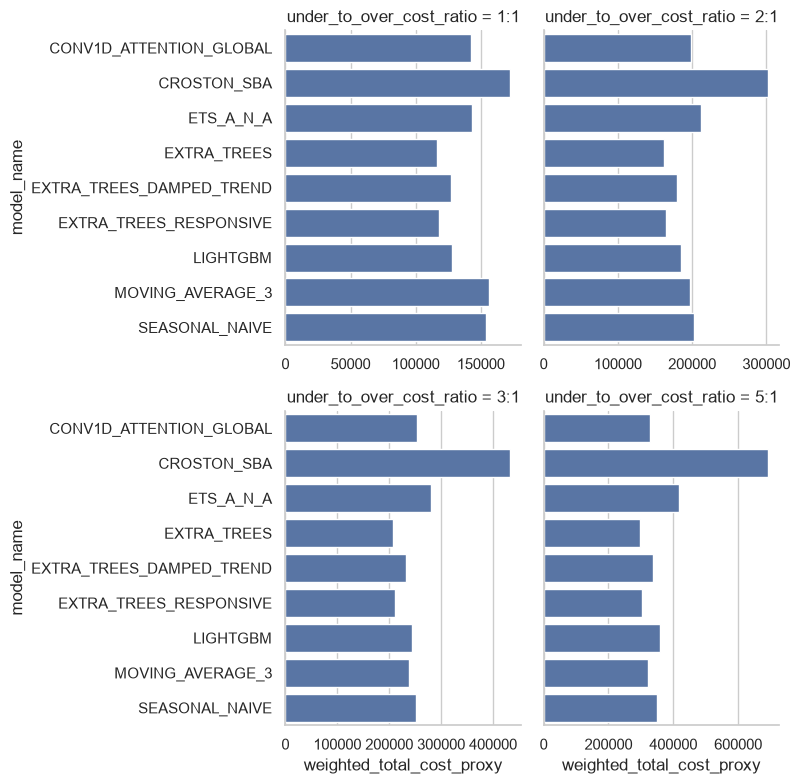

In [5]:
cost=pd.read_csv(EVAL/'decision_cost_sensitivity.csv')
primary_cost=cost[cost.population.eq('RM_PM_PRIMARY')]
display(primary_cost.sort_values(['under_to_over_cost_ratio','weighted_total_cost_proxy']))
display(cost[cost.population.eq('FG_SECONDARY')].sort_values(['under_to_over_cost_ratio','weighted_total_cost_proxy']))
sns.catplot(data=primary_cost,x='weighted_total_cost_proxy',y='model_name',col='under_to_over_cost_ratio',kind='bar',col_wrap=2,sharex=False,height=4); plt.show()

The 1:1, 2:1, 3:1 and 5:1 results are sensitivity evidence. No cost ratio is promoted to a production objective until shortage, holding and service costs are supplied and approved.